In [2]:
"""
COMPLETE OAKLAND POLICE STOP ANALYSIS
Two-Stage Analysis with Final Variable Selection
  Stage 1 - Search Decision: Who gets searched? (Diagnostic)
  Stage 2 - Outcome Test: Were searches equally productive? (Predictive/Prescriptive)

Final Control Variables:
  - Legal: primary_reason (extracted from reason_for_stop)
  - Temporal: stop_hour, nighttime (derived from time)
  - Demographic: subject_sex

Variables Excluded:
  - subject_age: 77% missing
  - officer_assignment: 91% missing
  - search_basis: 70% missing + target leakage in Stage 1
  - beat: 54% missing + 129 unique categories
  - All raw_subject_* columns: redundant with cleaned variables
  - use_of_force_description: free text, outside scope
"""

'\nCOMPLETE OAKLAND POLICE STOP ANALYSIS\nTwo-Stage Analysis with Final Variable Selection\n  Stage 1 - Search Decision: Who gets searched? (Diagnostic)\n  Stage 2 - Outcome Test: Were searches equally productive? (Predictive/Prescriptive)\n\nFinal Control Variables:\n  - Legal: primary_reason (extracted from reason_for_stop)\n  - Temporal: stop_hour, nighttime (derived from time)\n  - Demographic: subject_sex\n\nVariables Excluded:\n  - subject_age: 77% missing\n  - officer_assignment: 91% missing\n  - search_basis: 70% missing + target leakage in Stage 1\n  - beat: 54% missing + 129 unique categories\n  - All raw_subject_* columns: redundant with cleaned variables\n  - use_of_force_description: free text, outside scope\n'

In [3]:
#Necessary Imports for Machine Learning and Data Mining
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix,classification_report,roc_auc_score,roc_curve,auc)


# Step 1:
### Load Data

In [4]:
df = pd.read_csv(
    'ca_oakland_2020_04_01.csv',
    dtype={
        'subject_race': 'category',
        'subject_sex': 'category',
        'search_conducted': 'boolean',
        'contraband_found': 'boolean',
        'reason_for_stop': 'str',
        'time': 'str',
    },
    low_memory=False
)
print(f"Total stops : {len(df):,}")
print(f"Columns : {df.columns.tolist()}")

%matplotlib inline

Total stops : 133,407
Columns : ['raw_row_number', 'date', 'time', 'location', 'lat', 'lng', 'beat', 'subject_age', 'subject_race', 'subject_sex', 'officer_assignment', 'type', 'arrest_made', 'citation_issued', 'warning_issued', 'outcome', 'contraband_found', 'contraband_drugs', 'contraband_weapons', 'search_conducted', 'search_basis', 'reason_for_stop', 'use_of_force_description', 'raw_subject_sdrace', 'raw_subject_resultofencounter', 'raw_subject_searchconducted', 'raw_subject_typeofsearch', 'raw_subject_resultofsearch']


In [5]:
df

,raw_row_number,date,time,location,lat,lng,beat,subject_age,subject_race,subject_sex,...,contraband_weapons,search_conducted,search_basis,reason_for_stop,use_of_force_description,raw_subject_sdrace,raw_subject_resultofencounter,raw_subject_searchconducted,raw_subject_typeofsearch,raw_subject_resultofsearch
0,17213,NaN,01:33:00,E. 28th St. & Park BLVD,37.803084,-122.237247,NaN,NaN,asian/pacific islander,female,...,NaN,False,NaN,Traffic Violation,NaN,A,"Citation,",No,NaN,NaN
1,17214,NaN,14:48:00,1759 SEMINARY AV,37.767568,-122.196820,NaN,NaN,black,male,...,False,True,other,Probation/Parole,NaN,B,"FI Report,",Yes,"Prob./Parole,",NaN
2,1,2013-04-01,00:00:00,31st St And Mlk Jr Way,37.820599,-122.270734,NaN,NaN,white,male,...,False,True,other,Traffic Violation,NaN,W,"Warning,",Yes,"Prob./Parole,",NaN
3,2,2013-04-01,00:01:00,3000 Block Of San Pablo Ave,37.821246,-122.276488,NaN,NaN,black,male,...,NaN,False,NaN,Traffic Violation,NaN,B,"FI Report,",No,NaN,NaN
4,19,2013-04-01,10:41:00,12th St/Broadway,37.802937,-122.271738,NaN,NaN,hispanic,female,...,NaN,False,NaN,Probable Cause,NaN,H,"Citation,",No,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
133402,140132,2017-12-31,04:10:00,1000 W. Grand Ave,37.815359,-122.280940,05X,29.0,black,male,...,False,True,other,Traffic Violation,handcuffed,B,Misdemeanor Arrest,Yes,Probation/Parole,"Marijuana - Returned,Narcotics,Other Evidence,"
133403,140133,2017-12-31,04:15:00,2600 TELEGRAPH AV,37.815652,-122.267577,14X,50.0,black,male,...,False,True,other,Traffic Violation,handcuffed,B,Warning,Yes,Probation/Parole,"Narcotics,"
133404,140134,2017-12-31,04:15:00,600 Blk Of West Grand Ave,37.812546,-122.271570,06X,39.0,black,male,...,False,True,other,Probable Cause,handcuffed,B,Felony Arrest,Yes,Incident to Arrest,"Narcotics,Other Evidence,"
133405,140135,2017-12-31,07:00:00,2ND & WEBSTER ST,37.795119,-122.273958,01X,53.0,hispanic,male,...,NaN,False,NaN,Probable Cause,NaN,H,No Action,No,No,NaN


# Step 2: 
### Check missing  and unique Data

In [6]:

crucial_cols = ['subject_race', 'subject_sex', 'subject_age', 
                 'search_conducted', 'contraband_found', 'reason_for_stop',
                 'beat', 'officer_assignment', 'search_basis', 'time']
for col in crucial_cols:
    missing = df[col].isna().sum()
    print(f"{col}: {missing:,} missing ({missing/len(df):.1%})")


subject_race: 0 missing (0.0%)
subject_sex: 90 missing (0.1%)
subject_age: 102,724 missing (77.0%)
search_conducted: 0 missing (0.0%)
contraband_found: 92,250 missing (69.1%)
reason_for_stop: 0 missing (0.0%)
beat: 72,424 missing (54.3%)
officer_assignment: 121,431 missing (91.0%)
search_basis: 92,250 missing (69.1%)
time: 2 missing (0.0%)


#### Note: 90 rows are missing from subject_sex, they can be droppped later. We find that 77% of columns have subject_age missing. This variable will likely have to be omitted. 70% is missing from contrabound_found, but further testing will be done since it could be due to few searches being conducted. Beat has 54% missing data; model inclusion will be decided later after further testing. Officer_assignment has 91% missing data, and search_basis has around 70% missing data; both can be omitted from modeling. Time has 2 missing values. Rows can be dropped.

In [7]:
for col in crucial_cols:
    unique_count = df[col].nunique()
    print(f"{col}: {unique_count:,} unique values")


subject_race: 5 unique values
subject_sex: 2 unique values
subject_age: 84 unique values
search_conducted: 2 unique values
contraband_found: 2 unique values
reason_for_stop: 113 unique values
beat: 129 unique values
officer_assignment: 20 unique values
search_basis: 3 unique values
time: 1,439 unique values


#### Note: Beat has too many unique values for one hot encoder to be effective. Omission is advised. Reason_for_stop must be investigated further since it is a more crucial control variable. Omitting it entirely would mean less focus on race's individual impact on search rate.

## Step 2.1 
### Investigate missing and unique Data

### 2.1 Investigate missing contraband_found data

In [8]:
 print("Cross-tabulation of search_conducted vs contraband_found:")
 crosstab = pd.crosstab(
    df['search_conducted'],
    df['contraband_found'].isna(),
    margins=True)
crosstab.index = ['No Search', 'Search Conducted', 'Total']
crosstab.columns = ['contraband_found Present', 'contraband_found Missing', 'Total']
print(crosstab)

Cross-tabulation of search_conducted vs contraband_found:
                  contraband_found Present  contraband_found Missing   Total
No Search                                0                     92250   92250
Search Conducted                     41157                         0   41157
Total                                41157                     92250  133407


#### Note : There is no missing contraband_found data when a search is conducted, which means there is no cause for concern.

### 2.2 Investigate unique reason_for_stop data

In [9]:
reason_counts = df['reason_for_stop'].value_counts()
print(f"\nTop 20 stop reasons:")
print(reason_counts.head(20).to_string())


Top 20 stop reasons:
reason_for_stop
Traffic Violation                         99847
Probable Cause                            18643
Reasonable Suspicion                       8038
Consensual Encounter                       3998
Probation/Parole                           2451
Probable Cause|Reasonable Suspicion          51
Traffic Violation|Probable Cause             35
Probable Cause|Traffic Violation             30
Reasonable Suspicion|Probable Cause          21
Probable Cause|Probation/Parole              19
Probable Cause|Consensual Encounter          18
Traffic Violation|Consensual Encounter       16
Traffic Violation|Probation/Parole           15
Probation/Parole|Probable Cause              15
Probation/Parole|Reasonable Suspicion        11
Reasonable Suspicion|Traffic Violation       11
Consensual Encounter|Traffic Violation       10
Traffic Violation|Reasonable Suspicion        8
Probation/Parole|Consensual Encounter         8
Consensual Encounter|Probable Cause           7


In [10]:
print(f"\nBottom 20 stop reasons:")
print(reason_counts.tail(20).to_string())


Bottom 20 stop reasons:
reason_for_stop
Consensual Encounter|Consensual Encounter|Traffic Violation                                                                         1
Reasonable Suspicion|Probable Cause|Reasonable Suspicion|Reasonable Suspicion|Probable Cause                                        1
Reasonable Suspicion|Consensual Encounter|Probable Cause                                                                            1
Probation/Parole|Probable Cause|Traffic Violation                                                                                   1
Reasonable Suspicion|Probable Cause|Traffic Violation|Probable Cause|Reasonable Suspicion|Reasonable Suspicion|Traffic Violation    1
Probable Cause|Traffic Violation|Reasonable Suspicion                                                                               1
Probation/Parole|Probation/Parole|Reasonable Suspicion                                                                              1
Probable Cause|Probab

#### Note: There are only 5 primary stop reasons. Every other listing is a combination of values from such reasons. We can grab the primary reason for the model. 

## Step 3
### Complete Data Cleaning

### 3.1 drop null subject_sex and time rows (FIX LATER)

In [11]:
print(f"Initial records: {len(df):,}")
df = df.dropna(subset=['subject_sex'])
print(f"Records remaining: {len(df):,}")
df = df.dropna(subset=['time'])
print(f"Records remaining: {len(df):,}")

Initial records: 133,407
Records remaining: 133,317
Records remaining: 133,315


#### Note: A little under 100 total rows dropped. 

### 3.2 filling null values in contraband_found with false

In [12]:
# set_option to prevent error from ocurring
pd.set_option('future.no_silent_downcasting', True)
df.loc[df['search_conducted'] == False, 'contraband_found'] = False
print(df['contraband_found'])

0         False
1         False
2         False
3         False
4         False
          ...  
133402     True
133403     True
133404     True
133405    False
133406    False
Name: contraband_found, Length: 133315, dtype: boolean


### 3.3 Extract Primary reason from reason_for_stop

In [13]:
df['primary_reason'] = (
    df['reason_for_stop']
    .str.replace(',', '', regex=False) # removes commas for 2 instances    
    .str.replace('Other-Consensual', 'Consensual Encounter', regex=False)  # applicable for one typo
    .str.split('|').str[0]                    
    .str.strip()                               
)
print(df['primary_reason'].value_counts().to_string())

primary_reason
Traffic Violation       99890
Probable Cause          18781
Reasonable Suspicion     8100
Consensual Encounter     4030
Probation/Parole         2514


In [14]:
print(df['subject_race'].value_counts())

subject_race
black                     78907
hispanic                  26254
white                     15623
asian/pacific islander     8099
other                      4432
Name: count, dtype: int64


### Step 3.4 Extract hour from time column and create nighttime column

In [15]:
df['stop_hour'] = pd.to_datetime(df['time'], errors='coerce').dt.hour    
df['nighttime'] = ((df['stop_hour'] >= 21) | (df['stop_hour'] <= 5)).astype(int) 
print(f"stop_hour range: {df['stop_hour'].min()}:00 to {df['stop_hour'].max()}:00")
print(f"Nighttime stops: {df['nighttime'].mean():.1%}")

/var/folders/s6/c17wb1m10n14dnnysspxc8zc0000gn/T/ipykernel_42759/1341523787.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['stop_hour'] = pd.to_datetime(df['time'], errors='coerce').dt.hour


stop_hour range: 0:00 to 23:00
Nighttime stops: 31.2%


## Step 4: Defining features

In [16]:
numeric_features = ['stop_hour']
binary_features = ['nighttime']
categorical_features = ['subject_race', 'subject_sex', 'primary_reason']

In [17]:
preprocessor = ColumnTransformer([
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler',StandardScaler())]),numeric_features),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features),
    ('bin', 'passthrough', binary_features)
])

In [18]:
all_features = numeric_features + categorical_features + binary_features
all_features

['stop_hour', 'subject_race', 'subject_sex', 'primary_reason', 'nighttime']

## Step 5 : Search Decision Modeling (Stage 1)

In [19]:
stage1 = df.dropna(subset=all_features)
X1 = stage1[all_features]
y1 = stage1['search_conducted'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X1, y1, test_size=0.2, random_state=42, stratify=y1
)

In [20]:
model1 = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42))
])
model1.fit(X_train, y_train)

y_pred = model1.predict(X_test)
y_proba = model1.predict_proba(X_test)[:,1]

In [21]:
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba)}")
print(classification_report(y_test, y_pred, target_names=['No Search', 'Search']))

ROC-AUC: 0.7948137899025027
              precision    recall  f1-score   support

   No Search       0.81      0.89      0.84     18432
      Search       0.67      0.52      0.59      8231

    accuracy                           0.77     26663
   macro avg       0.74      0.70      0.72     26663
weighted avg       0.76      0.77      0.77     26663



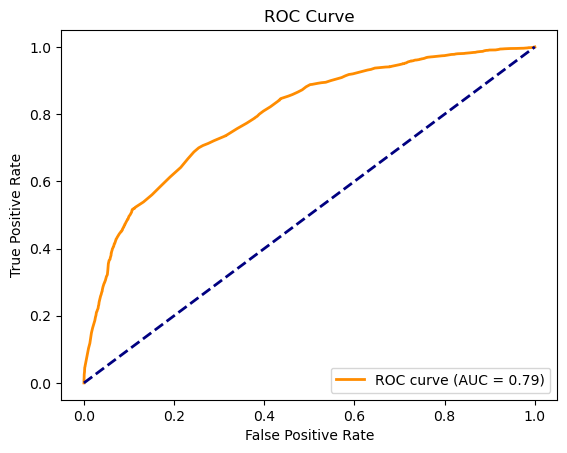

In [22]:
fpr,tpr,thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Random guess baseline
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()
                                   

Deepseek assisted

In [23]:
ohe = model1.named_steps['preprocessor'].named_transformers_['cat']
feature_names = numeric_features + list(ohe.get_feature_names_out(categorical_features)) + binary_features
odds_ratios = np.exp(model1.named_steps['classifier'].coef_[0])

importance = pd.DataFrame({'Feature': feature_names, 'Odds_Ratio': odds_ratios})
importance['Abs'] = np.abs(np.log(importance['Odds_Ratio']))
importance = importance.sort_values('Odds_Ratio', ascending=False)

print("\nTop features (Odds Ratios):")
print(importance[['Feature', 'Odds_Ratio']].to_string(index=False))


Top features (Odds Ratios):
                            Feature  Odds_Ratio
    primary_reason_Probation/Parole   12.943612
      primary_reason_Probable Cause    3.809466
                 subject_race_black    3.309623
                   subject_sex_male    2.473915
primary_reason_Reasonable Suspicion    2.169107
              subject_race_hispanic    1.937749
                 subject_race_other    1.041238
                          stop_hour    1.028693
                 subject_race_white    0.934183
                          nighttime    0.883364
   primary_reason_Traffic Violation    0.334150


In [24]:
print("\nTop features (Odds Ratios):")
importance2 = importance.sort_values('Abs', ascending=False)
print(importance2[['Feature', 'Abs']].to_string(index=False))


Top features (Odds Ratios):
                            Feature      Abs
    primary_reason_Probation/Parole 2.560602
      primary_reason_Probable Cause 1.337489
                 subject_race_black 1.196834
   primary_reason_Traffic Violation 1.096166
                   subject_sex_male 0.905802
primary_reason_Reasonable Suspicion 0.774316
              subject_race_hispanic 0.661527
                          nighttime 0.124018
                 subject_race_white 0.068083
                 subject_race_other 0.040411
                          stop_hour 0.028289


In [25]:
print("\nRace coefficients:")
for f in feature_names:
    if 'subject_race' in f:
        row = importance[importance['Feature'] == f]
        race = f.replace('subject_race_', '')
        print(f"  {race}: Odds Ratio = {row['Odds_Ratio'].values[0]:.2f}")
print("  asian/pacific islander: Odds Ratio = 1.00 (reference)")


Race coefficients:
  black: Odds Ratio = 3.31
  hispanic: Odds Ratio = 1.94
  other: Odds Ratio = 1.04
  white: Odds Ratio = 0.93
  asian/pacific islander: Odds Ratio = 1.00 (reference)


## Step 6 Stage 2 : Outcome Test

In [26]:
searches = df[df['search_conducted'] == True].dropna(subset=all_features)
X2 = searches[all_features]
y2 = searches['contraband_found'].astype(int)
print(f"Searched stops: {len(searches):,}")
print(f"Hit rate: {y2.mean():.1%}")

Searched stops: 41,154
Hit rate: 14.9%


In [27]:
X_train2, X_test2, y_train2, y_test2, race_train2, race_test2 = train_test_split(
    X2, y2, searches['subject_race'], test_size=0.2, random_state=42, stratify=y2
)
model2 = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=2000, random_state=42))
])
model2.fit(X_train2, y_train2)

y_proba2 = model2.predict_proba(X_test2)[:, 1]

In [28]:
results = pd.DataFrame({
    'race': race_test2.values,
    'actual': y_test2.values,
    'predicted': y_proba2
})
print("\nOutcome Test Results:")
for race in results['race'].unique():
    g = results[results['race'] == race]
    if len(g) < 30:
        continue
    actual = g['actual'].mean()
    predicted = g['predicted'].mean()
    ratio = actual / predicted
    print(f"  {race}: actual={actual:.1%}, predicted={predicted:.1%}, ratio={ratio:.2f}", end="")
    if ratio < 0.85:
        print(" → LOWER threshold")
    elif ratio > 1.15:
        print(" → HIGHER threshold")
    else:
        print(" → Similar threshold")


Outcome Test Results:
  black: actual=14.4%, predicted=14.5%, ratio=0.99 → Similar threshold
  hispanic: actual=17.2%, predicted=16.5%, ratio=1.04 → Similar threshold
  asian/pacific islander: actual=11.7%, predicted=14.5%, ratio=0.81 → LOWER threshold
  white: actual=17.7%, predicted=16.6%, ratio=1.06 → Similar threshold
  other: actual=10.3%, predicted=12.5%, ratio=0.82 → LOWER threshold


# Step 7 : Visualizations

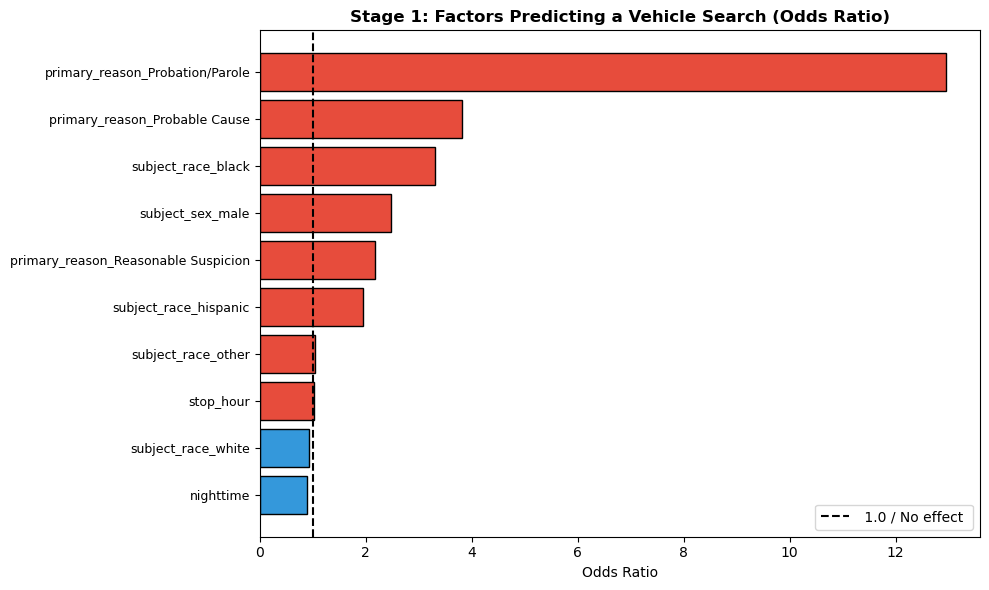

In [29]:
# --- Chart 1: Odds Ratios ---
plt.figure(figsize=(10, 6))

top_odds = importance.head(10).sort_values('Odds_Ratio')
colors = ['#e74c3c' if o > 1 else '#3498db' for o in top_odds['Odds_Ratio'].values]

plt.barh(range(len(top_odds)), top_odds['Odds_Ratio'].values, color=colors, edgecolor='black')
plt.yticks(range(len(top_odds)), top_odds['Feature'].values, fontsize=9)
plt.axvline(x=1, color='black', linestyle='--', linewidth=1.5, label=' 1.0 / No effect ')
plt.xlabel('Odds Ratio')
plt.title('Stage 1: Factors Predicting a Vehicle Search (Odds Ratio)', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('stage1_odds_ratios.png', dpi=150, bbox_inches='tight')
plt.show()


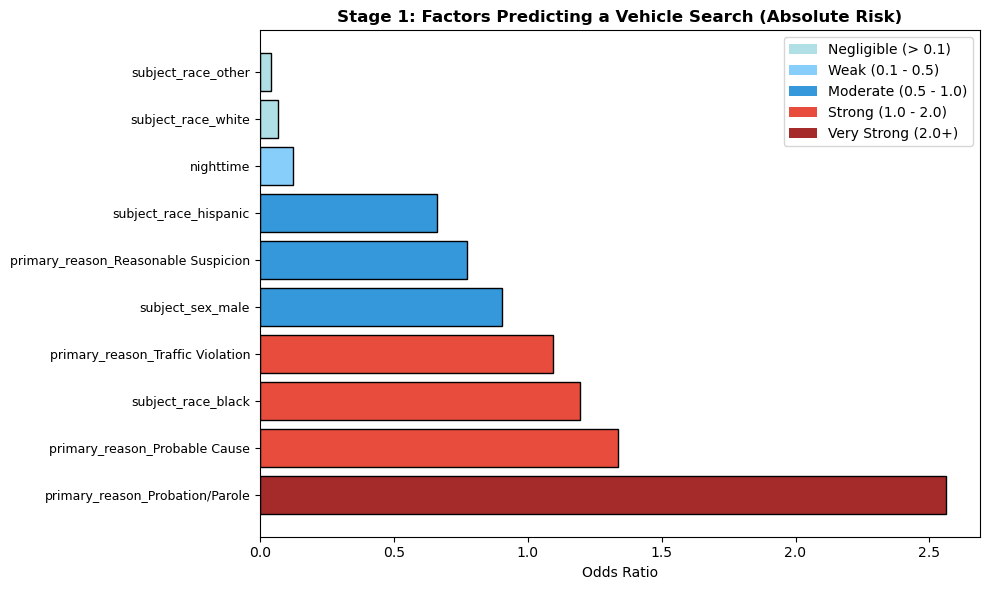

In [30]:
# --- Chart 1: Odds Ratios ---
plt.figure(figsize=(10, 6))
top_abs = importance2.head(10).sort_values('Abs')

def get_color(value):
    if value > 2.0:
        return 'brown'      
    elif value > 1.0:
        return '#e74c3c'   
    elif value > 0.5:
        return '#3498db'   
    elif value > 0.1:
        return 'lightskyblue'      
    else:
        return 'powderblue'    

colors2 = [get_color(v) for v in top_abs['Abs'].values]

plt.barh(range(len(top_abs)), top_abs['Abs'].values,color = colors2,edgecolor='black')
plt.yticks(range(len(top_abs)), top_abs['Feature'].values, fontsize=9)
plt.xlabel('Odds Ratio')
plt.title('Stage 1: Factors Predicting a Vehicle Search (Absolute Risk)', fontweight='bold')



legend_elements = [
    Patch(facecolor='powderblue', label='Negligible (> 0.1)'),
    Patch(facecolor='lightskyblue', label='Weak (0.1 - 0.5)'),
    Patch(facecolor='#3498db', label='Moderate (0.5 - 1.0)'),
    Patch(facecolor='#e74c3c', label='Strong (1.0 - 2.0)'),
    Patch(facecolor='brown', label='Very Strong (2.0+)')
]
plt.legend(handles=legend_elements)

plt.gca().invert_yaxis()

plt.tight_layout()
plt.savefig('stage1_abs.png', dpi=150, bbox_inches='tight')
plt.show()


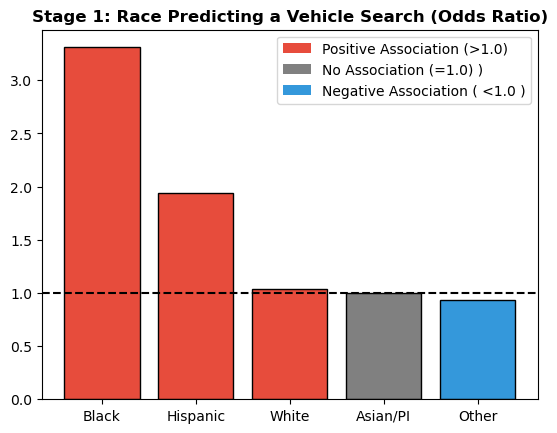

In [31]:
# Chart 2 Racial Odds Ratios
races = ['Black', 'Hispanic',  'White','Asian/PI', 'Other']
OddsGr = [3.31,1.94,1.04,1.00,0.93]
x = np.arange(len(races))
w = 0.35

def get_color2(value):
    if value > 1:
        return '#e74c3c'      
    elif value == 1.0:
        return 'grey'    
    else:
        return '#3498db'    
colors3 = [get_color2(v) for v in OddsGr]
plt.bar(x,OddsGr,color = colors3, edgecolor='black')
plt.xticks(x, races)
plt.axhline(y=1, color='black', linestyle='--', linewidth=1.5, label='1.0 / No Effect')
legend_elements3 = [
    Patch(facecolor = '#e74c3c', label = 'Positive Association (>1.0) '),
    Patch(facecolor = 'grey', label = 'No Association (=1.0) )'),
    Patch(facecolor = '#3498db', label = 'Negative Association ( <1.0 )')
]
plt.legend(handles = legend_elements3)
plt.title('Stage 1: Race Predicting a Vehicle Search (Odds Ratio)', fontweight='bold')
plt.show()

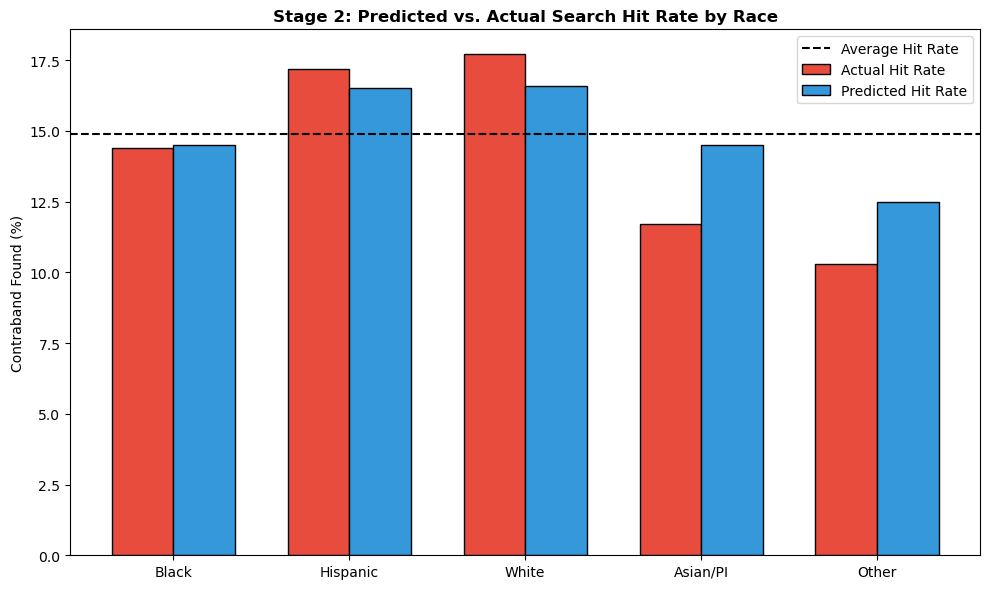

In [32]:
# --- Chart 2: Outcome Test ---
plt.figure(figsize=(10, 6))

actual = [14.4, 17.2,  17.7,11.7, 10.3]
predicted = [14.5, 16.5, 16.6,14.5, 12.5]


plt.bar(x - w/2, actual, w, label='Actual Hit Rate', color='#e74c3c', edgecolor='black')
plt.bar(x + w/2, predicted, w, label='Predicted Hit Rate', color='#3498db', edgecolor='black')
plt.xticks(x, races)
plt.ylabel('Contraband Found (%)')
plt.title('Stage 2: Predicted vs. Actual Search Hit Rate by Race', fontweight='bold')
plt.axhline(y=14.9, color='black', linestyle='--', linewidth=1.5, label='Average Hit Rate')
plt.legend()
plt.tight_layout()
plt.show()